### Use default bb band to figure out the consolidation periods

In [ ]:
from pandas_ta.volatility import bbands
import sys

sys.path.append("../../../src/")
from sts.data.sp500 import sp500_yh_data
from sts.plots import plot_multi_time_series

In [9]:
df = sp500_yh_data.history(["TSLA"], period="5y")

In [19]:
df_bb = bbands(df["Close"], length=22)

In [28]:
df_bb["bbc"] = (df_bb["BBB_22_2.0"] < 15.0) * 1.0

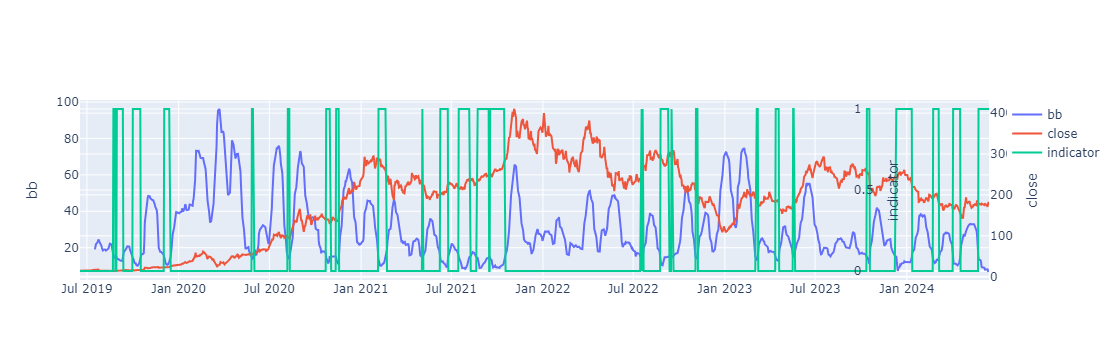

In [29]:
plot_multi_time_series(
    [df_bb["BBB_22_2.0"], df["Close"], df_bb["bbc"]],
    name_list=["bb", "close", "indicator"],
    yaxis_list=["y1", "y2", "y3"],
    yaxis_left=[True, False, False],
)

 bb band can help to find out the compression zone. We'd like to have a compression zone when the band width get narrow and volatility is maller enough, and typically average trading volume also decayed for some times. Which is the consolidation periods, when the decay speed is small enough, we would expect some break through will come soon. how long the consolidation is can be figured out from the time bb band start decay? 